In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.basemap import Basemap
from numpy import *
from shapely.geometry import Polygon, Point
import shapefile
from scipy.stats import pearsonr
from matplotlib.colors import Normalize
from matplotlib.patches import Polygon

/home/hungday/anaconda3/envs/dataVis/lib/python3.11/site-packages/pyproj/__init__.py:89: UserWarning: pyproj unable to set database path.
  _pyproj_global_context_initialize()


### EX 1

['An Giang', 'Ba Ria - Vung Tau', 'Bac Giang', 'Bac Kan', 'Bac Lieu', 'Bac Ninh', 'Ben Tre', 'Binh Dinh', 'Binh Duong', 'Binh Phuoc', 'Binh Thuan', 'Ca Mau', 'Can Tho', 'Cao Bang', 'Da Nang', 'Dak Lak', 'Dak Nong', 'Dien Bien', 'Dong Nai', 'Dong Thap', 'Gia Lai', 'Ha Giang', 'Ha Nam', 'Ha Noi', 'Ha Tinh', 'Hai Duong', 'Hai Phong', 'Hau Giang', 'Ho Chi Minh', 'Hoa Binh', 'Hung Yen', 'Khanh Hoa', 'Kien Giang', 'Kon Tum', 'Lai Chau', 'Lam Dong', 'Lang Son', 'Lao Cai', 'Long An', 'Nam Dinh', 'Nghe An', 'Ninh Binh', 'Ninh Thuan', 'Phu Tho', 'Phu Yen', 'Quang Binh', 'Quang Nam', 'Quang Ngai', 'Quang Ninh', 'Quang Tri', 'Soc Trang', 'Son La', 'Tay Ninh', 'Thai Binh', 'Thai Nguyen', 'Thanh Hoa', 'Thua Thien Hue', 'Tien Giang', 'Tra Vinh', 'Tuyen Quang', 'Vinh Long', 'Vinh Phuc', 'Yen Bai']


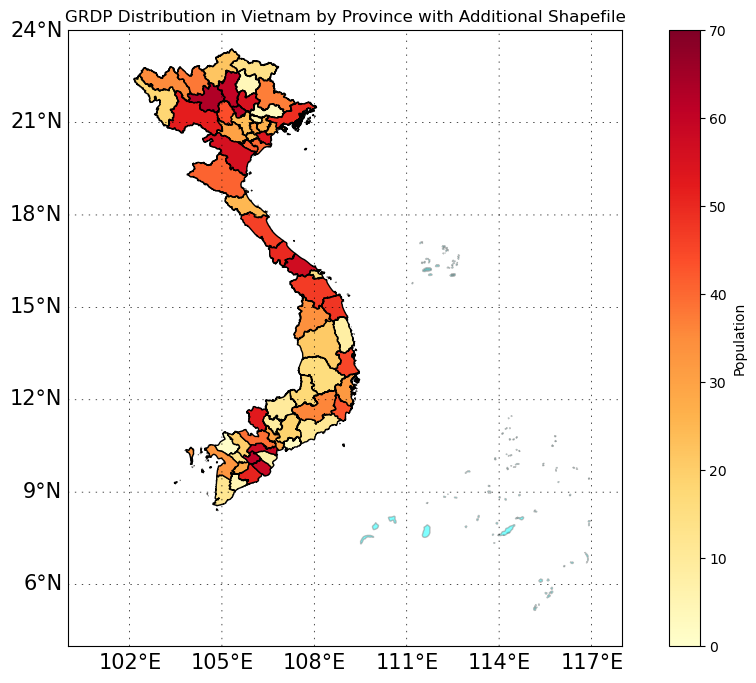

In [2]:
import shapefile
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
from matplotlib.colors import Normalize
from matplotlib.patches import Polygon
import numpy as np

# Load the two shapefiles
sf1 = shapefile.Reader("gadm41_VNM_0/gadm41_VNM_1.shp")
sf2 = shapefile.Reader("Islands/haidao.shp")

# Extract province names from the first shapefile (assuming record index 4 contains the province name)
records1 = sf1.records()
province_names = [record[4] for record in records1]

# Print extracted province names to verify
print(province_names)

# Generate fake data about the population
population = np.arange(1, 64, 1)

# Create a figure and axis
fig, ax = plt.subplots(1, figsize=(12, 8))

# Create a Basemap instance
map2 = Basemap(projection='cyl', llcrnrlon=100, llcrnrlat=4, urcrnrlon=118, urcrnrlat=24, resolution='l', epsg=4326)

# Draw parallels and meridians
parallels = np.arange(-180., 180, 3)
meridians = np.arange(-180., 180., 3)
map2.drawparallels(parallels, linewidth=0.5, dashes=[2, 8], labels=[1, 0, 0, 0], fontsize=15, zorder=12)
map2.drawmeridians(meridians, linewidth=0.5, dashes=[2, 8], labels=[0, 0, 0, 1], fontsize=15, zorder=12)

# Normalize the population data for coloring
norm = Normalize(vmin=0, vmax=70)

# Plot the first shapefile with population data
for shape, pop in zip(sf1.shapes(), population):
    poly_points = shape.points
    parts = list(shape.parts) + [len(poly_points)]  # Get indices of parts
    for i in range(len(parts) - 1):  # Loop through polygon parts
        sub_shape = poly_points[parts[i]:parts[i + 1]]
        if sub_shape[0] != sub_shape[-1]:  # Ensure the polygon is closed
            sub_shape.append(sub_shape[0])
        poly = Polygon(sub_shape, fill=True, edgecolor='k', facecolor=plt.cm.YlOrRd(norm(pop)))
        ax.add_patch(poly)

# Plot the second shapefile (haidao.shp) in a different color for distinction
for shape in sf2.shapes():
    poly_points = shape.points
    parts = list(shape.parts) + [len(poly_points)]  # Handle parts for multi-part polygons
    for i in range(len(parts) - 1):
        sub_shape = poly_points[parts[i]:parts[i + 1]]
        if sub_shape[0] != sub_shape[-1]:  # Ensure the polygon is closed
            sub_shape.append(sub_shape[0])
        poly = Polygon(sub_shape, fill=True, edgecolor='gray', facecolor='cyan', alpha=0.5)  # Adjust transparency
        ax.add_patch(poly)

# Set title and axis limits
ax.set_title('GRDP Distribution in Vietnam by Province with Additional Shapefile')
ax.set_xlim(100, 118)
ax.set_ylim(4, 24)

# Add a colorbar for the first shapefile
sm = plt.cm.ScalarMappable(cmap=plt.cm.YlOrRd, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('Population')

# Show the combined map
plt.show()



### EX 2

In [3]:
# vietnam = gpd.read_file('/home/dell/Documents/DataVisual/lab4/gadm41_VNM_shp/gadm41_VNM_1.shp')
# haidao = gpd.read_file('/home/dell/Documents/DataVisual/lab4/dao/haidao.shp')

# fig, ax = plt.subplots(1, figsize=(12,8))
# lon_min=100
# lon_max=118
# lat_min=4
# lat_max=24

# map2=Basemap(projection='merc',llcrnrlon=lon_min,llcrnrlat=lat_min,
#              urcrnrlon=lon_max,urcrnrlat=lat_max,resolution='i',epsg=4326)

# parallels = arange(-90.,150, around((lat_max-lat_min)/4, decimals=1)) 
# meridians = arange(0.,180., around((lon_max-lon_min)/4, decimals=1))

# map2.drawparallels(parallels,linewidth=0.5,dashes=[2,8],labels=[1,0,0,0],fontsize=12, zorder=12) # left, right, top or bottom
# map2.drawmeridians(meridians,linewidth=0.5,dashes=[2,8],labels=[0,0,0,1],fontsize=12, zorder=12)


# map2.fillcontinents()

# population = arange(1, 64, 1)
# vietnam.plot(column=population, cmap='YlOrRd', linewidth=0.8, ax=ax, edgecolor='0.8', legend=True)
# haidao.plot(cmap='YlOrRd', linewidth=0.8, ax=ax, edgecolor='0.8', legend=True)

# ax.set_title('GRDP in Vietnam by Province')

# plt.show()


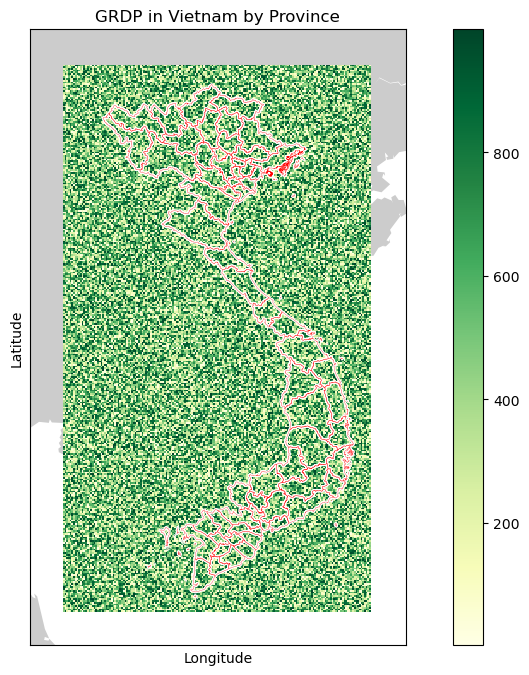

In [4]:
#----#----#----#----#----#----#
# NOW WITH THE DATA
#----#----#----#----#----#----#

x_axis = arange(101, 110, 0.05)
y_axis = arange(8, 24, 0.05)

x_axis, y_axis = meshgrid(x_axis, y_axis)
random.seed(seed=180793)

data = random.randint(1, 1000, size = (size(x_axis,0), size(x_axis, 1)))


# Create a figure and axis
fig, ax = plt.subplots(1, figsize=(12, 8))

map2 = Basemap(projection='merc',llcrnrlon=100,llcrnrlat=7,
    urcrnrlon=111,urcrnrlat=25,resolution='l',epsg=4326)

map2.fillcontinents()
plt.pcolormesh(x_axis, y_axis, data, cmap = 'YlGn')

map2.readshapefile('gadm41_VNM_0/gadm41_VNM_1','gadm41_VNM_1',
	linewidth=2, color='white')

map2.readshapefile('gadm41_VNM_0/gadm41_VNM_1','gadm41_VNM_1',
	linewidth=0.2, color='r')

# Set the title and labels
ax.set_title('GRDP in Vietnam by Province')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

plt.colorbar()

# Show the map
plt.show()


Total shapes: 63


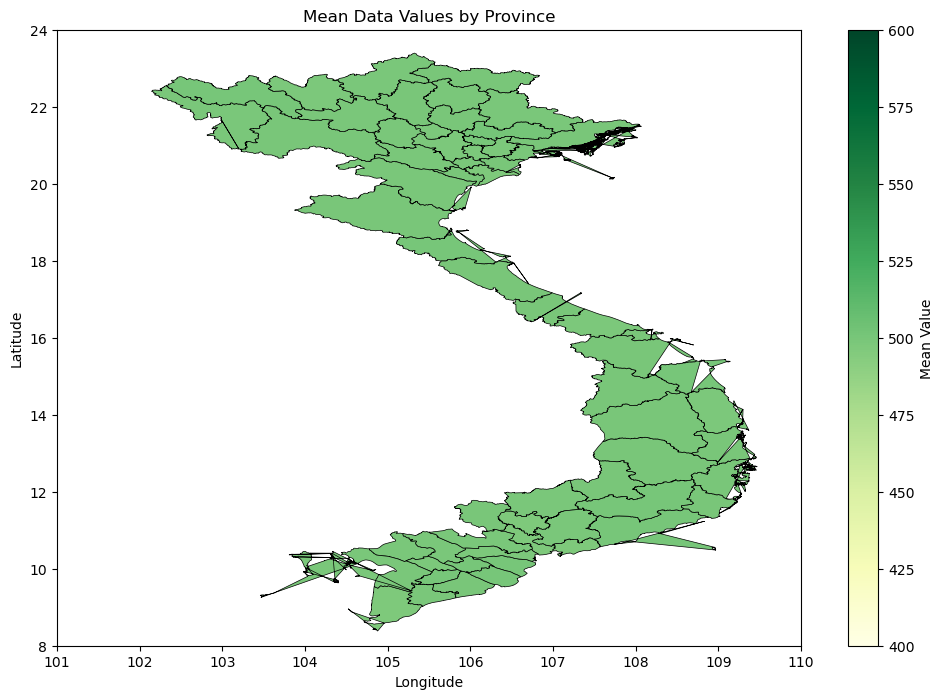

In [ ]:
import shapefile
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.path import Path
from matplotlib.patches import Polygon
from matplotlib.colors import Normalize
from matplotlib import cm

# Open the shapefile using the pyshp library
sf = shapefile.Reader('gadm41_VNM_0/gadm41_VNM_1','gadm41_VNM_1.shp')
shape_data1 = sf.shapes()

print(f"Total shapes: {len(shape_data1)}")  # Total number of provinces (63)

# Generate random data with finer grid resolution
x_axis = np.arange(101, 110, 0.01)  # Reduced step size for higher resolution
y_axis = np.arange(8, 24, 0.01)
x_axis, y_axis = np.meshgrid(x_axis, y_axis)

random.seed(180793)
data = random.randint(400, 600, size=(np.size(x_axis, 0), np.size(x_axis, 1)))

# Initialize arrays to store mean values
mean_values = []

# Process each province in the shapefile
for i in range(len(shape_data1)):
    n_point = len(shape_data1[i].points)
    lon_data = np.zeros((n_point))
    lat_data = np.zeros((n_point))

    # Extract the points for the current shape
    for j, p in enumerate(shape_data1[i].points):
        lon_data[j] = p[0]
        lat_data[j] = p[1]

    # Create a Path object for the current shape
    poly_path = Path(np.column_stack((lon_data, lat_data)))

    # Create a mask of points inside the polygon
    points = np.vstack((x_axis.ravel(), y_axis.ravel())).T
    mask = poly_path.contains_points(points).reshape(x_axis.shape)

    # Extract data values inside the polygon
    data_inside = data[mask]

    # Calculate the mean value of points inside the polygon
    if len(data_inside) > 0:
        mean_values.append(np.mean(data_inside))
    else:
        mean_values.append(np.nan)  # Assign NaN if no data points are inside

# Normalize the mean values for plotting
norm = Normalize(vmin=400, vmax=600)
cmap = cm.YlGn
colors = [cmap(norm(value)) if not np.isnan(value) else (1, 1, 1, 1) for value in mean_values]

# Create a figure and axis
fig, ax = plt.subplots(1, figsize=(12, 8))

# Draw the polygons with colors based on mean values
for i, shape in enumerate(shape_data1):
    n_point = len(shape.points)
    lon_data = np.zeros((n_point + 1))  # Add one more point to ensure closure
    lat_data = np.zeros((n_point + 1))

    # Extract polygon points
    for j, p in enumerate(shape.points):
        lon_data[j] = p[0]
        lat_data[j] = p[1]

    # Check if the polygon is closed; if not, close it by appending the first point
    if shape.points[0] != shape.points[-1]:
        lon_data[-1] = shape.points[0][0]
        lat_data[-1] = shape.points[0][1]
    else:
        lon_data = lon_data[:-1]  # Remove the extra point if already closed
        lat_data = lat_data[:-1]

    # Create a Polygon and add it to the plot
    polygon = Polygon(np.column_stack((lon_data, lat_data)),
                      facecolor=colors[i],
                      edgecolor='black',
                      lw=0.5)
    ax.add_patch(polygon)

# Add a colorbar for the mean values
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, orientation='vertical')
cbar.set_label('Mean Value')

# Set plot limits and labels
ax.set_xlim(101, 110)
ax.set_ylim(8, 24)
ax.set_title('Mean Data Values by Province')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

# Show the map
plt.show()




In [6]:
def calculate_data_by_province(shapefile_path, x_axis_range, y_axis_range, data_size, random_seed=None):
    # Set the random seed if provided for reproducibility
    if random_seed is not None:
        np.random.seed(random_seed)
    
    # Generate x and y axis values and data
    x_axis = np.arange(x_axis_range[0], x_axis_range[1], 0.05)
    y_axis = np.arange(y_axis_range[0], y_axis_range[1], 0.05)
    x_mesh, y_mesh = np.meshgrid(x_axis, y_axis)
    
    # Generate random data corresponding to the size of x_mesh and y_mesh
    data = np.random.randint(1, 1000, size=(x_mesh.shape[0], x_mesh.shape[1]))
    
    # Load the shapefile
    sf = shapefile.Reader(shapefile_path)
    
    # Create a list of polygons from the shapefile
    poly_list = [Polygon(shape.points) for shape in sf.shapes()]
    
    # Get bounding boxes for all shapes
    bound_list = [sf.shapes()[i].bbox for i in range(len(sf.shapes()))]
    
    # Initialize a list to store data for each province
    data_list = [[] for _ in range(len(poly_list))]
    
    # Iterate over all provinces (polygons)
    for i, poly in enumerate(poly_list):
        bbox = bound_list[i]  # Bounding box for the province
        
        # Iterate through x and y coordinates within bounding box limits
        for j, x_val in enumerate(x_axis):
            if bbox[0] <= x_val <= bbox[2]:  # Check x-axis bounds
                for k, y_val in enumerate(y_axis):
                    if bbox[1] <= y_val <= bbox[3]:  # Check y-axis bounds
                        if poly.contains(Point(x_val, y_val)):
                            data_list[i].append(data[k, j])
    
    # Calculate the mean for each province's data
    data_by_province = [np.mean(data) if data else 0 for data in data_list]
    
    return np.array(data_by_province)

# Usage example
shapefile_path = "gadm41_VNM_0/gadm41_VNM_1.shp"
x_axis_range = (101, 110)
y_axis_range = (8, 24)
data_size = (500, 500)  # Example size of random data (use actual size)
random_seed = 180793

data_by_province = calculate_data_by_province(shapefile_path, x_axis_range, y_axis_range, data_size, random_seed=random_seed)

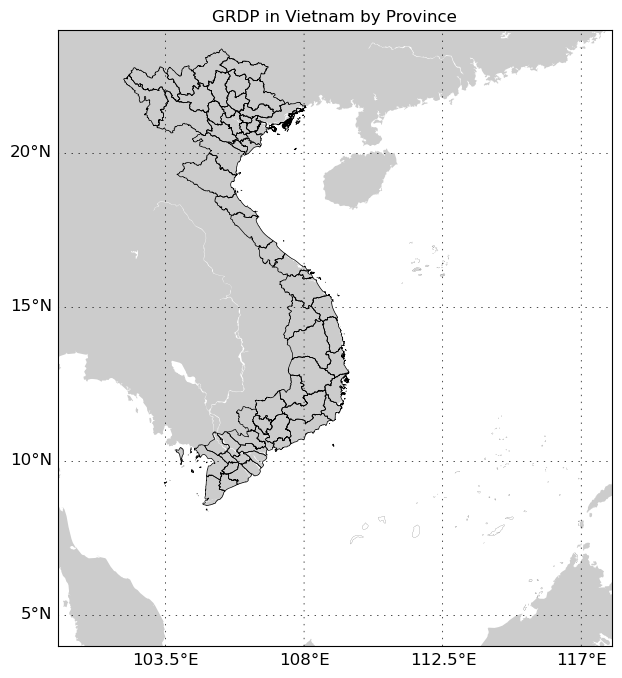

In [7]:
fig, ax = plt.subplots(1, figsize=(12,8))
lon_min=100
lon_max=118
lat_min=4
lat_max=24

map2=Basemap(projection='merc',llcrnrlon=lon_min,llcrnrlat=lat_min,
             urcrnrlon=lon_max,urcrnrlat=lat_max,resolution='i',epsg=4326)

parallels = arange(-90.,150, around((lat_max-lat_min)/4, decimals=1)) 
meridians = arange(0.,180., around((lon_max-lon_min)/4, decimals=1))

map2.drawparallels(parallels,linewidth=0.5,dashes=[2,8],labels=[1,0,0,0],fontsize=12, zorder=12) # left, right, top or bottom
map2.drawmeridians(meridians,linewidth=0.5,dashes=[2,8],labels=[0,0,0,1],fontsize=12, zorder=12)


map2.fillcontinents()

population = arange(1, 64, 1)
map2.readshapefile('gadm41_VNM_0/gadm41_VNM_1', 'provinces', linewidth=0.5)
map2.readshapefile('Islands/haidao','haidao',linewidth=0.1)

ax.set_title('GRDP in Vietnam by Province')

plt.show()


In [8]:
A = array([10.,  6.,  8.,  9.,  4.,  5.,  9.,  9.,  3.,  9.,  5.,  9.,  7.,
       9.,  5.,  5.,  8.,  2.,  8.,  4.,  3., 12.,  5.,  7.,  4.,  7.,
       6.,  8.,  4.,  8.,  9.,  6., 14.,  5., 11., 14., 17.,  6.,  5.])
B = array([ 5.,  6.,  8., 12.,  2.,  7.,  5.,  7.,  4.,  7.,  4.,  2.,  4.,
              5.,  0.,  7.,  7.,  2.,  5.,  3.,  2.,  5.,  3., 12.,  7.,  8.,
              2.,  7.,  2.,  4.,  7.,  7.,  4., 10.,  4.,  7.,  8.,  7.,  6.])
C = array([10.,  5.,  3.,  6.,  5.,  6.,  2.,  7.,  5.,  3.,  3.,  1.,  4.,
              9.,  4.,  7.,  3.,  4.,  2.,  3.,  0.,  5.,  2.,  7.,  0.,  6.,
              4.,  7.,  6.,  4., 10.,  7.,  2.,  5.,  3.,  6.,  7.,  2.,  1.])
D = array([4., 6., 4., 7., 3., 7., 3., 6., 9., 2., 4., 2., 2., 3., 0., 8., 9.,
              4., 9., 6., 6., 4., 6., 2., 2., 9., 2., 6., 4., 6., 7., 7., 3., 5.,
              9., 6., 6., 7., 4.])
E = array([ 3.,  3.,  1.,  3.,  2.,  4.,  5.,  1.,  5.,  3.,  6.,  3.,  1.,
              4.,  3.,  6.,  7.,  7., 10.,  4.,  1.,  7.,  9.,  3.,  2., 12.,
              4.,  7.,  3.,  6.,  9.,  7.,  7.,  8.,  9.,  5.,  9.,  8., 12.])
F = array([ 2.,  7.,  5.,  5.,  4., 13.,  7.,  7.,  8.,  3., 10.,  6.,  4.,
              9.,  5., 14.,  4., 13.,  9.,  6.,  2.,  6., 10.,  1.,  2.,  9.,
              0.,  8.,  5.,  4.,  7.,  5.,  4.,  4.,  5.,  5.,  9.,  1.,  5.])
G = array([ 2., 10.,  2.,  2.,  1.,  6.,  1., 11.,  4.,  6., 10.,  6.,  9.,
              10.,  4.,  4.,  4., 11., 13.,  6.,  2., 10.,  7.,  4.,  4.,  5.,
              3.,  1.,  3.,  3., 10.,  1.,  7.,  2.,  3.,  8.,  5.,  6.,  5.])
H = array([ 4.,  5.,  4.,  5.,  3.,  1.,  4.,  6.,  5.,  3.,  6.,  2.,  3.,
              3.,  3., 13.,  3.,  3., 13.,  8.,  9.,  7.,  6.,  8.,  2., 13.,
              13., 11.,  9.,  6., 12.,  6.,  7., 12., 13., 11., 12., 15., 10.])
I = array([ 6.,  3.,  0.,  4.,  0.,  3.,  3.,  3.,  1.,  1., 10.,  0.,  6.,
              7.,  2.,  4.,  1.,  2., 10.,  4.,  4.,  3., 10.,  5.,  9.,  7.,
              4.,  9.,  2.,  6.,  8.,  2.,  8.,  8., 14., 20., 16., 19., 13.])
J = array([ 8.,  7.,  2.,  7.,  1.,  4.,  4.,  7.,  7.,  4.,  7.,  2., 12.,
              12.,  7., 13.,  5., 10., 11.,  1.,  1.,  3.,  6.,  4.,  6.,  4.,
              4.,  3.,  0.,  1., 10.,  3.,  6.,  5.,  1.,  4.,  1.,  4.,  8.])

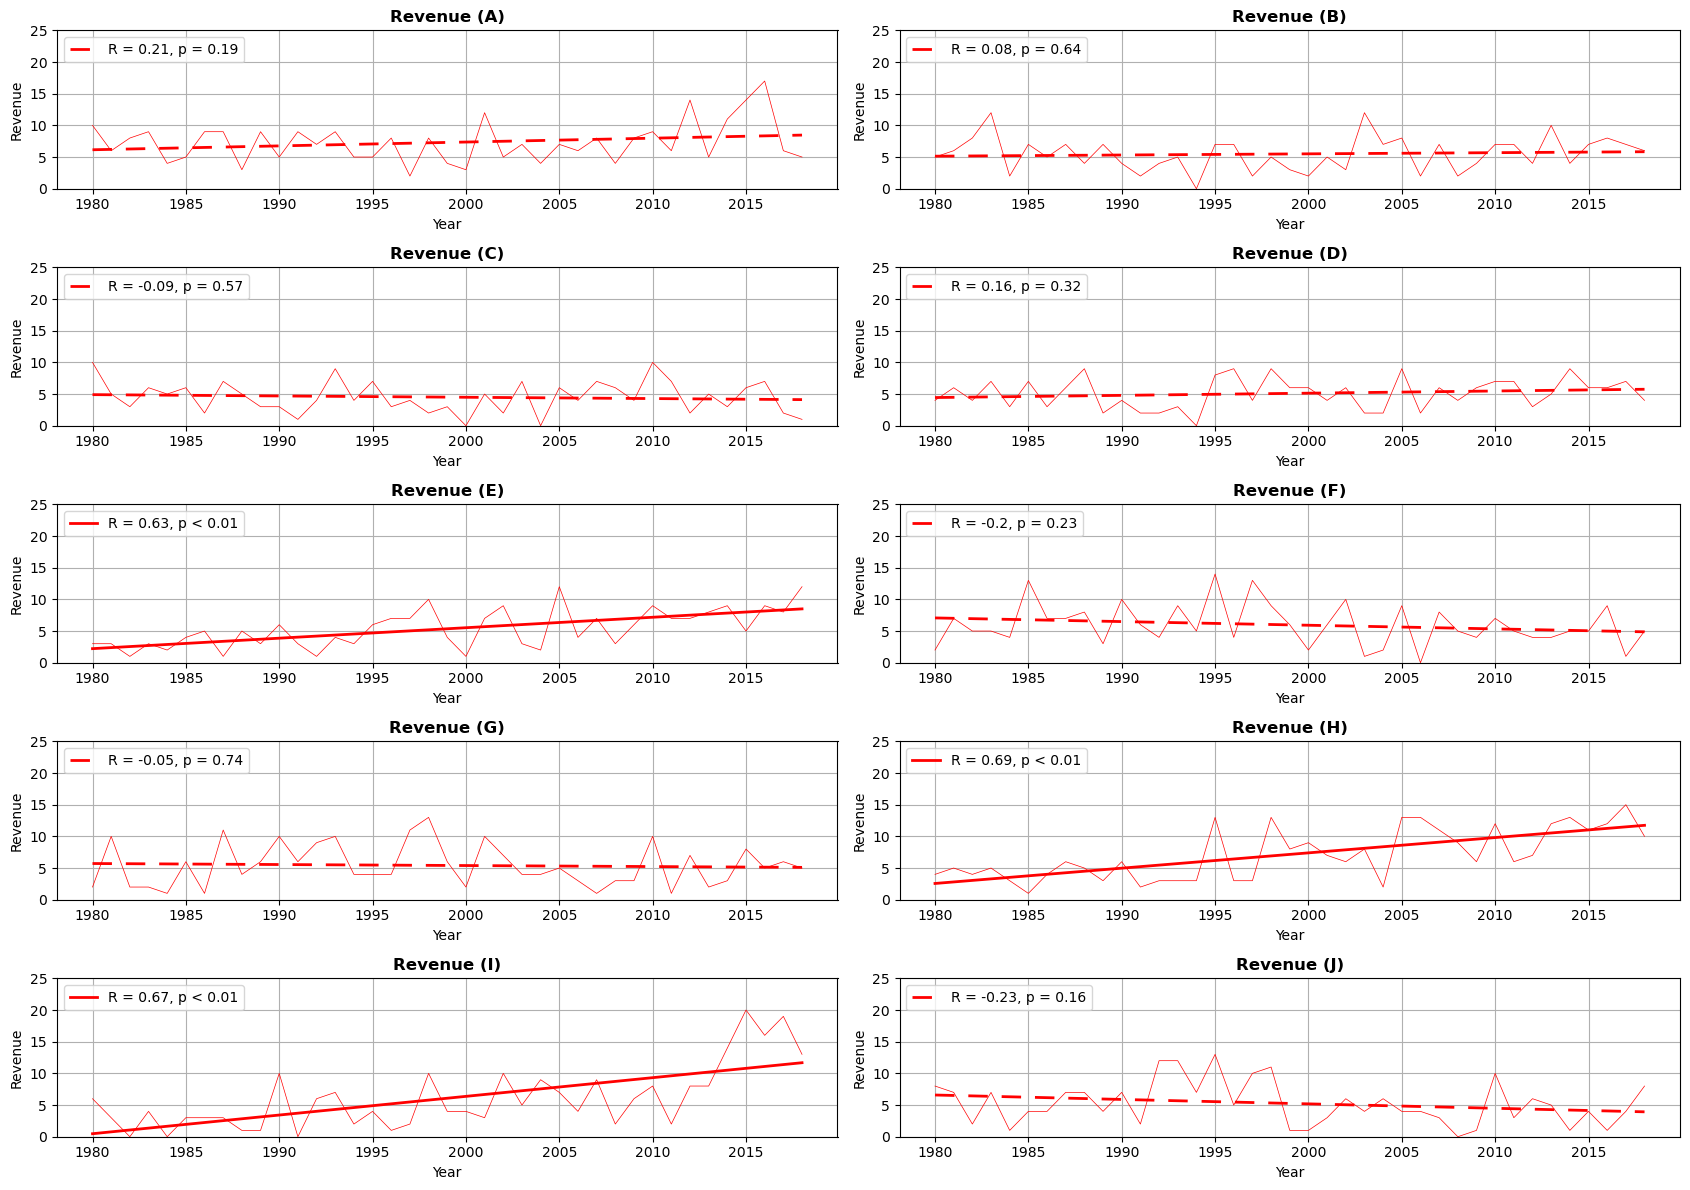

In [9]:
def plot_revenues(*datasets, labels, ylabel='Revenue'):
    list_year = np.arange(1980, 2019, 1)
    num_datasets = len(datasets)
    
    # Create a figure with subplots arranged in a grid (e.g., 2 columns)
    fig, axes = plt.subplots(nrows=(num_datasets + 1) // 2, ncols=2, figsize=(17, 12))  # Adjust size as needed
    axes = axes.flatten()  # Flatten axes for easy iteration if grid has multiple rows

    for i, data in enumerate(datasets):
        ax = axes[i]
        ax.grid()
        ax.set_ylim(0, 25)
        
        # Plotting the data
        ax.plot(list_year, data, color='red', linewidth=0.5)
        
        # Fitting and plotting the trend line
        z = np.polyfit(list_year, data, 1)
        p = np.poly1d(z)
        corr, p_value = pearsonr(list_year, data)
        
        if p_value < 0.05:
            trend_line_predict, = ax.plot(list_year, p(list_year), "red", linewidth=2)
        else:
            trend_line_predict, = ax.plot(list_year, p(list_year), "red", dashes=[7, 5], linewidth=2)
        
        # Create legend for the trend line
        if p_value < 0.01:
            ax.legend([trend_line_predict], [f'R = {round(corr, 2)}, p < 0.01'], loc='upper left')
        else:
            ax.legend([trend_line_predict], [f'R = {round(corr, 2)}, p = {round(p_value, 2)}'], loc='upper left')
        
        # Set title and labels
        ax.set_title(f"Revenue ({labels[i]})", fontweight='bold')
        ax.set_ylabel(ylabel)
        ax.set_xlabel('Year')

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
    
    plt.tight_layout()
    plt.show()

plot_revenues(A, B, C, D, E, F, G, H, I, J, labels=["A", "B", "C", "D", "E", "F", "G", "H", "I", "J"])

